In [18]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report, confusion_matrix
import random
import numpy as np

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [19]:
train_path = "Teeth_Dataset/Training"
val_path = "Teeth_Dataset/Validation"
test_path = "Teeth_Dataset/Testing"

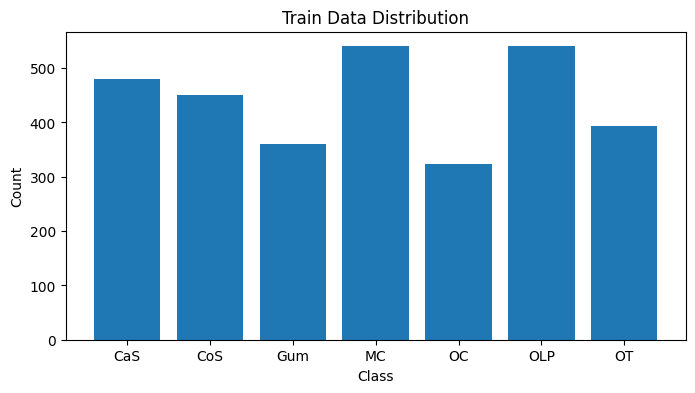

In [20]:
classes = os.listdir(train_path)
counts = []
for c in classes:
    counts.append(len(os.listdir(os.path.join(train_path, c))))

plt.figure(figsize=(8, 4))
plt.bar(classes, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Train Data Distribution")
plt.show()

In [21]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [22]:
train_data = ImageFolder(root=train_path, transform=train_transform)
val_data = ImageFolder(root=val_path, transform=test_transform)
test_data = ImageFolder(root=test_path, transform=test_transform)

In [23]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [24]:
model = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Flatten(),
    nn.Linear(64 * 16 * 16, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, len(train_data.classes))
)

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

In [26]:
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct / total
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc = 100 * val_correct / val_total
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.2f}%")

Epoch 1/10 | Train Loss: 1.8946 Acc: 20.99% | Val Loss: 1.7447 Acc: 32.49%
Epoch 2/10 | Train Loss: 1.7322 Acc: 31.55% | Val Loss: 1.6088 Acc: 37.65%
Epoch 3/10 | Train Loss: 1.6031 Acc: 37.87% | Val Loss: 1.4372 Acc: 43.29%
Epoch 4/10 | Train Loss: 1.4876 Acc: 42.89% | Val Loss: 1.3326 Acc: 52.14%
Epoch 5/10 | Train Loss: 1.3884 Acc: 46.94% | Val Loss: 1.2479 Acc: 51.65%
Epoch 6/10 | Train Loss: 1.3097 Acc: 50.79% | Val Loss: 1.1668 Acc: 59.05%
Epoch 7/10 | Train Loss: 1.2245 Acc: 54.29% | Val Loss: 1.0703 Acc: 60.41%
Epoch 8/10 | Train Loss: 1.1370 Acc: 57.50% | Val Loss: 0.9655 Acc: 65.37%
Epoch 9/10 | Train Loss: 1.0455 Acc: 61.39% | Val Loss: 0.9233 Acc: 67.90%
Epoch 10/10 | Train Loss: 0.9933 Acc: 63.46% | Val Loss: 0.8637 Acc: 69.46%


In [27]:
torch.save(model.state_dict(), "model.pth")

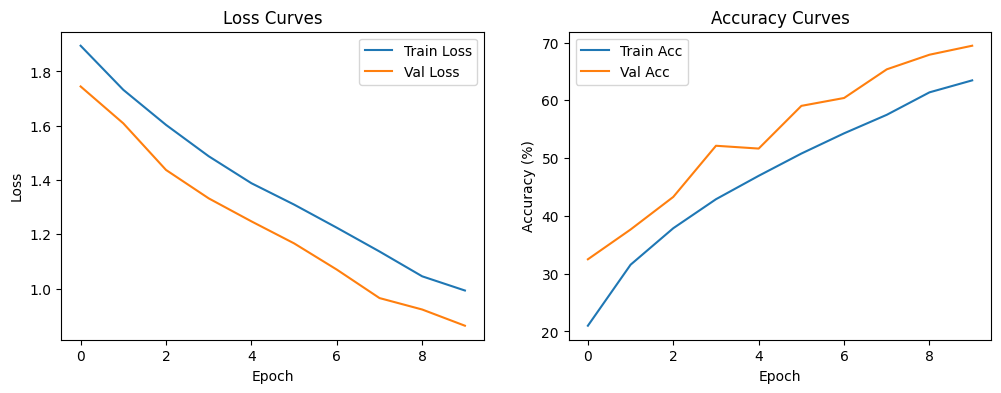

In [28]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curves")

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Acc")
plt.plot(val_accuracies, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Accuracy Curves")

plt.show()

In [29]:
model.eval()
test_preds = []
test_targets = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        
        test_preds.extend(predicted.cpu().numpy())
        test_targets.extend(labels.cpu().numpy())

              precision    recall  f1-score   support

         CaS       0.71      0.76      0.73       160
         CoS       0.86      0.72      0.79       149
         Gum       0.72      0.80      0.76       120
          MC       0.62      0.74      0.68       180
          OC       0.74      0.59      0.66       108
         OLP       0.72      0.64      0.68       180
          OT       0.70      0.72      0.71       131

    accuracy                           0.71      1028
   macro avg       0.72      0.71      0.71      1028
weighted avg       0.72      0.71      0.71      1028



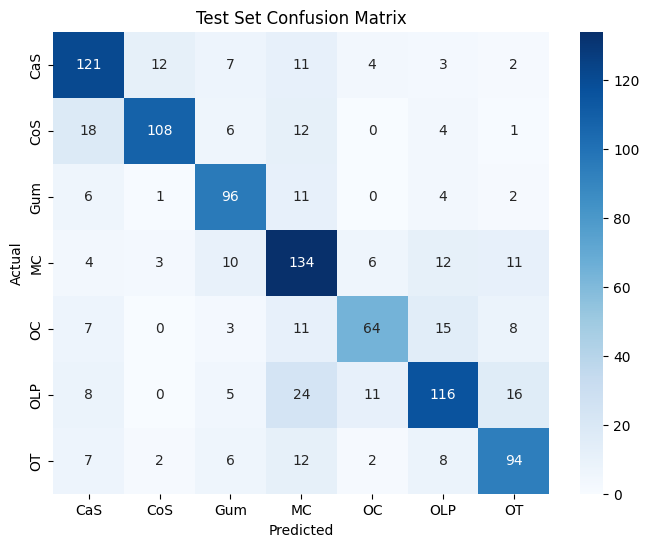

In [30]:
print(classification_report(test_targets, test_preds, target_names=train_data.classes))

cm = confusion_matrix(test_targets, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=train_data.classes, yticklabels=train_data.classes, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Set Confusion Matrix")
plt.show()